In [38]:
# import os
# import json
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import re

# # --- Configuration ---
# # Use the full path to your results directory
# BASE_DIR = os.path.expanduser('~/kgqa/runs/medqa_usmle_hf-new')
# SEEDS = ['seed_42', 'seed_123', 'seed_456', 'seed_789', 'seed_1011'] # Add all your seed directory names
# FULL_DATA_SIZE = 10000 # Define a numerical value for the 'full' dataset for plotting

# # --- Data Parsing and Loading ---

# def parse_run_name(run_name):
#     """Parses the experiment run name to extract synthetic and real data sizes."""
#     synth_size = 0
#     real_size_str = "0"

#     # Find synthetic data size
#     synth_match = re.search(r'synth_(\d+)', run_name)
#     if synth_match:
#         synth_size = int(synth_match.group(1))

#     # Find real data size
#     train_match = re.search(r'train_(\w+)', run_name)
#     if train_match:
#         real_size_str = train_match.group(1)
        
#     # Handle cases with only synthetic data (no 'train_' part)
#     elif not train_match and synth_match:
#         real_size_str = "0"
        
#     # Handle cases with only real data (double hyphen is a good indicator)
#     elif '--train' in run_name:
#         synth_size = 0

#     return synth_size, real_size_str

# data = []
# print(f"Searching for results in: {BASE_DIR}")

# # Walk through the directory structure to find result files
# for seed_dir in SEEDS:
#     seed_path = os.path.join(BASE_DIR, seed_dir)
#     if not os.path.isdir(seed_path):
#         print(f"Warning: Directory not found for seed '{seed_dir}'. Skipping.")
#         continue
        
#     for root, dirs, files in os.walk(seed_path):
#         if 'eval_results.json' in files:
#             # The run name is the directory containing the 'model' subdirectory
#             run_name = os.path.basename(os.path.dirname(root))
            
#             try:
#                 # Parse the sizes from the directory name
#                 synth_size, real_label = parse_run_name(run_name)
                
#                 if real_label == 'full':
#                     real_num = FULL_DATA_SIZE
#                 else:
#                     real_num = int(real_label)

#                 # Load the score from the JSON file
#                 json_path = os.path.join(root, 'eval_results.json')
#                 with open(json_path, 'r') as f:
#                     results = json.load(f)
#                     score = results.get('eval_accuracy')
#                     if score is not None:
#                         data.append([seed_dir, synth_size, real_num, real_label, score])

#             except (ValueError, TypeError) as e:
#                 print(f"Could not parse run '{run_name}'. Error: {e}. Skipping.")


# # Create DataFrame from all collected data points
# if not data:
#     raise ValueError("No data found! Please check your BASE_DIR and SEEDS configuration.")

# df_raw = pd.DataFrame(data, columns=["seed", "synthetic", "real_num", "real_label", "score"])

# # Aggregate data to get mean and std dev
# df_agg = df_raw.groupby(["synthetic", "real_num", "real_label"]).agg(
#     score_mean=('score', 'mean'),
#     score_std=('score', 'std')
# ).reset_index()


# # --- Plotting ---

# # 1. Line Plot with Confidence Interval (Standard Deviation)
# plt.figure(figsize=(12, 7))
# palette = sns.color_palette("viridis", n_colors=df_agg["synthetic"].nunique())

# for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
#     label = f"Synth {synth_size}" if synth_size > 0 else "Baseline (Real Only)"
#     plt.plot(group["real_num"], group["score_mean"], marker="o", linestyle="-", label=label, color=palette[i])
#     plt.fill_between(
#         group["real_num"],
#         group["score_mean"] - group["score_std"],
#         group["score_mean"] + group["score_std"],
#         alpha=0.2,
#         color=palette[i]
#     )

# plt.title("BioLinkBERT: Effect of Synthetic Data on Performance (Mean ± Std Dev)")
# plt.xlabel("Real Training Size")
# plt.ylabel("Mean Accuracy Score")
# xticks_vals = sorted(df_agg["real_num"].unique())
# xticks_labels = [str(x) if x != FULL_DATA_SIZE else "full" for x in xticks_vals]
# plt.xticks(xticks_vals, xticks_labels)
# plt.legend(title="Synthetic Data Size")
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()


# # 2. Heatmap of Mean Scores
# pivot_df = df_agg.pivot(index="synthetic", columns="real_label", values="score_mean")
# # Ensure columns are in a logical order
# column_order = sorted(df_agg['real_label'].unique(), key=lambda x: FULL_DATA_SIZE if x == 'full' else int(x))
# pivot_df = pivot_df[column_order]


# plt.figure(figsize=(10, 7))
# sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="viridis", linewidths=.5)
# plt.title("BioLinkBERT Performance Heatmap: Mean Accuracy of Synthetic vs. Real Data")
# plt.ylabel("Synthetic Data Size")
# plt.xlabel("Real Training Size")
# plt.show()


# # 3. Bar Chart with Automatic Error Bars (Confidence Intervals)
# plt.figure(figsize=(12, 7))
# sns.barplot(
#     data=df_raw,
#     x="real_label",
#     y="score",
#     hue="synthetic",
#     palette="viridis",
#     order=column_order  # Use the same logical order
# )
# plt.title("BioLinkBERT: Mean Accuracy per Real Training Size")
# plt.xlabel("Real Training Size")
# plt.ylabel("Mean Accuracy Score (with CI)")
# plt.legend(title="Synthetic Data Size")
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.show()

Searching for results in: /home/id.aau.dk/kr75cs/kgqa/runs/medqa_usmle_hf-new
Applying filter. Including runs with: ['--train', 'synth_5000', 'synth_10000', 'synth_20000']



--- Aggregated Data ---
    synthetic  real_num real_label  score_mean  score_std
0           0      1000       1000    0.268500   0.013173
1           0      2500       2500    0.307934   0.015059
2           0      5000       5000    0.398115   0.022750
3           0      7500       7500    0.396229   0.077964
4           0     10000       full    0.413668   0.067979
5        5000         0          0    0.203771   0.006633
6        5000      1000       1000    0.241948   0.008107
7        5000      2500       2500    0.331343   0.009400
8        5000      5000       5000    0.398429   0.013824
9        5000      7500       7500    0.427180   0.009218
10       5000     10000       full    0.446347   0.014857
11      10000         0          0    0.194815   0.006160
12      10000      1000       1000    0.230951   0.025660
13      10000      2500       2500    0.329929   0.015161
14      10000      5000       5000    0.397643   0.009755
15      10000      7500       7500    0.438492 

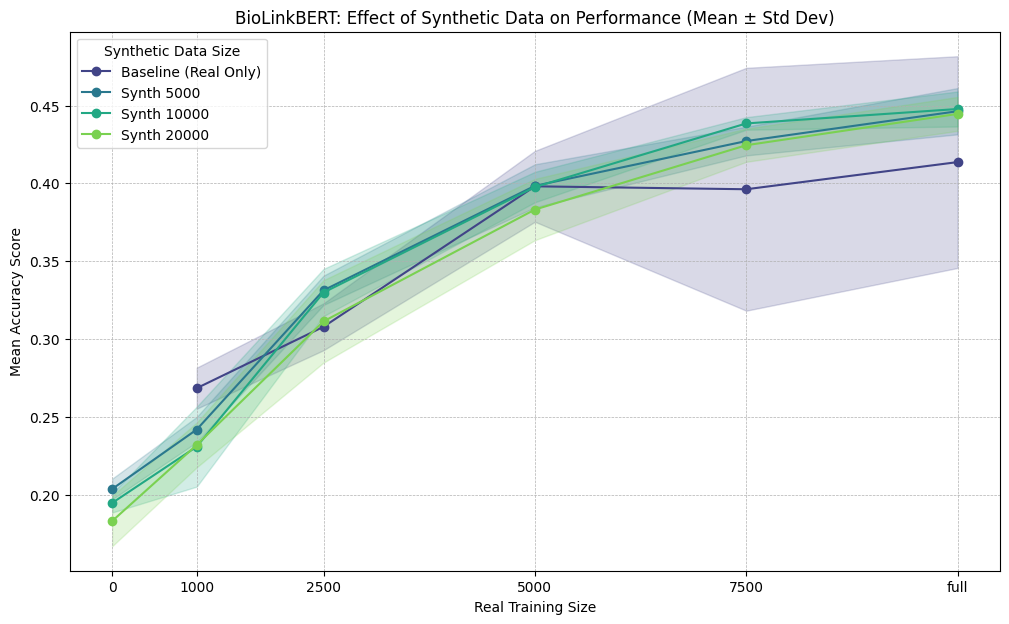

In [39]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy import stats


# --- Configuration ---
# Use the full path to your results directory
BASE_DIR = os.path.expanduser('~/kgqa/runs/medqa_usmle_hf-new')
SEEDS = ['seed_42', 
         'seed_123', 
         'seed_456', 
         'seed_789', 
         'seed_1011'
         ] # Add all your seed directory names
FULL_DATA_SIZE = 10000 # Define a numerical value for the 'full' dataset for plotting

# --- NEW: Filter for Debugging ---
# Add substrings to this list to only include runs that match.
# Leave empty (`[]`) to process all runs found in the directories.
# Example 1: To see only the baseline and the largest synthetic set:
RUN_FILTER = ["--train", "synth_5000", "synth_10000", "synth_20000"]
# Example 2: To focus only on experiments involving 5000 real samples:
# RUN_FILTER = ["train_5000"]
# RUN_FILTER = []


# --- Data Parsing and Loading ---

def parse_run_name(run_name):
    """Parses the experiment run name to extract synthetic and real data sizes."""
    synth_size = 0
    real_size_str = "0"

    # Find synthetic data size
    synth_match = re.search(r'synth_(\d+)', run_name)
    if synth_match:
        synth_size = int(synth_match.group(1))

    # Find real data size
    train_match = re.search(r'train_(\w+)', run_name)
    if train_match:
        real_size_str = train_match.group(1)
        
    # Handle cases with only synthetic data (no 'train_' part)
    elif not train_match and synth_match:
        real_size_str = "0"
        
    # Handle cases with only real data (double hyphen is a good indicator)
    elif '--train' in run_name:
        synth_size = 0

    return synth_size, real_size_str

data = []
print(f"Searching for results in: {BASE_DIR}")
if RUN_FILTER:
    print(f"Applying filter. Including runs with: {RUN_FILTER}")


# Walk through the directory structure to find result files
for seed_dir in SEEDS:
    seed_path = os.path.join(BASE_DIR, seed_dir)
    if not os.path.isdir(seed_path):
        print(f"Warning: Directory not found for seed '{seed_dir}'. Skipping.")
        continue
        
    for root, dirs, files in os.walk(seed_path):
        if 'predict_results.json' in files:
            # The run name is the directory containing the 'model' subdirectory
            run_name = os.path.basename(os.path.dirname(root))
            
            # <<< FILTERING LOGIC >>>
            # If a filter is active, check if the run name matches.
            # If not, skip to the next directory.
            if RUN_FILTER and not any(filt in run_name for filt in RUN_FILTER):
                continue
            
            try:
                # Parse the sizes from the directory name
                synth_size, real_label = parse_run_name(run_name)
                
                if real_label == 'full':
                    real_num = FULL_DATA_SIZE
                else:
                    real_num = int(real_label)

                # Load the score from the JSON file
                json_path = os.path.join(root, 'predict_results.json')
                with open(json_path, 'r') as f:
                    results = json.load(f)
                    score = results.get('test_accuracy')
                    if score is not None:
                        data.append([seed_dir, synth_size, real_num, real_label, score])

            except (ValueError, TypeError) as e:
                print(f"Could not parse run '{run_name}'. Error: {e}. Skipping.")


# Create DataFrame from all collected data points
if not data:
    raise ValueError("No data found! Please check your BASE_DIR and SEEDS configuration, or adjust your RUN_FILTER.")

df_raw = pd.DataFrame(data, columns=["seed", "synthetic", "real_num", "real_label", "score"])

# Aggregate data to get mean and std dev
df_agg = df_raw.groupby(["synthetic", "real_num", "real_label"]).agg(
    score_mean=('score', 'mean'),
    score_std=('score', 'std')
).reset_index()

print("\n--- Aggregated Data ---")
print(df_agg)
print("---------------------\n")


# --- Plotting ---

# 1. Line Plot with Confidence Interval (Standard Deviation)
plt.figure(figsize=(12, 7))
palette = sns.color_palette("viridis", n_colors=df_agg["synthetic"].nunique())

for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
    label = f"Synth {synth_size}" if synth_size > 0 else "Baseline (Real Only)"
    plt.plot(group["real_num"], group["score_mean"], marker="o", linestyle="-", label=label, color=palette[i])
    plt.fill_between(
        group["real_num"],
        group["score_mean"] - group["score_std"],
        group["score_mean"] + group["score_std"],
        alpha=0.2,
        color=palette[i]
    )

plt.title("BioLinkBERT: Effect of Synthetic Data on Performance (Mean ± Std Dev)")
plt.xlabel("Real Training Size")
plt.ylabel("Mean Accuracy Score")
xticks_vals = sorted(df_agg["real_num"].unique())
xticks_labels = [str(x) if x != FULL_DATA_SIZE else "full" for x in xticks_vals]
plt.xticks(xticks_vals, xticks_labels)
plt.legend(title="Synthetic Data Size")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


# # 2. Heatmap of Mean Scores
# try:
#     pivot_df = df_agg.pivot(index="synthetic", columns="real_label", values="score_mean")
#     # Ensure columns are in a logical order
#     column_order = sorted(df_agg['real_label'].unique(), key=lambda x: FULL_DATA_SIZE if x == 'full' else int(x))
#     pivot_df = pivot_df[column_order]

#     plt.figure(figsize=(10, 7))
#     sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="viridis", linewidths=.5)
#     plt.title("BioLinkBERT Performance Heatmap: Mean Accuracy of Synthetic vs. Real Data")
#     plt.ylabel("Synthetic Data Size")
#     plt.xlabel("Real Training Size")
#     plt.show()
# except Exception as e:
#     print(f"Could not generate heatmap, likely due to filtered data structure. Error: {e}")


# # 3. Bar Chart with Automatic Error Bars (Confidence Intervals)
# plt.figure(figsize=(12, 7))
# column_order = sorted(df_agg['real_label'].unique(), key=lambda x: FULL_DATA_SIZE if x == 'full' else int(x))
# sns.barplot(
#     data=df_raw,
#     x="real_label",
#     y="score",
#     hue="synthetic",
#     palette="viridis",
#     order=column_order
# )
# plt.title("BioLinkBERT: Mean Accuracy per Real Training Size")
# plt.xlabel("Real Training Size")
# plt.ylabel("Mean Accuracy Score (with CI)")
# plt.legend(title="Synthetic Data Size")
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.show()

# plt.figure(figsize=(12, 7))
# palette = sns.color_palette("viridis", n_colors=df_agg["synthetic"].nunique())

# # Calculate n (number of seeds) for CI calculation
# num_seeds = len(SEEDS)
# # Get the t-statistic for a 95% CI with n-1 degrees of freedom
# # For 5 seeds, degrees of freedom = 4. If you change the number of seeds, this will adapt.
# t_value = stats.t.ppf(0.975, df=num_seeds - 1) if num_seeds > 1 else 1.96

# for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
#     label = f"Synth {synth_size}" if synth_size > 0 else "Baseline (Real Only)"
    
#     # Calculate Standard Error of the Mean (SEM)
#     sem = group['score_std'] / np.sqrt(num_seeds)
#     # Calculate the 95% Confidence Interval margin
#     ci_margin = t_value * sem
    
#     plt.plot(group["real_num"], group["score_mean"], marker="o", linestyle="-", label=label, color=palette[i])
#     plt.fill_between(
#         group["real_num"],
#         group["score_mean"] - ci_margin,
#         group["score_mean"] + ci_margin,
#         alpha=0.2,
#         color=palette[i]
#     )

# plt.title("BioLinkBERT: Effect of Synthetic Data on Performance (Mean with 95% CI)")
# plt.xlabel("Real Training Size")
# plt.ylabel("Mean Accuracy Score")
# xticks_vals = sorted(df_agg["real_num"].unique())
# xticks_labels = [str(x) if x != FULL_DATA_SIZE else "full" for x in xticks_vals]
# plt.xticks(xticks_vals, xticks_labels)
# plt.legend(title="Synthetic Data Size")
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()

Searching for results in: /home/id.aau.dk/kr75cs/kgqa/runs/pubmedqa_hf-new
Applying filter. Including runs with: ['--train', 'synth_1000', 'synth_5000', 'synth_10000', 'synth_20000']

--- Aggregated Data ---
    synthetic  real_num real_label  score_mean  score_std
0           0       100        100    0.486000   0.035157
1           0       200        200    0.543333   0.077365
2           0       300        300    0.636667   0.035346
3           0       500       full    0.676667   0.042724
4        1000         0          0    0.552000   0.000000
5        1000       100        100    0.466667   0.010066
6        1000       200        200    0.558000   0.023065
7        1000       300        300    0.578667   0.018148
8        1000       500       full    0.646000   0.040150
9        5000         0          0    0.552000   0.002000
10       5000       100        100    0.644667   0.081298
11       5000       200        200    0.637333   0.078341
12       5000       300        300    

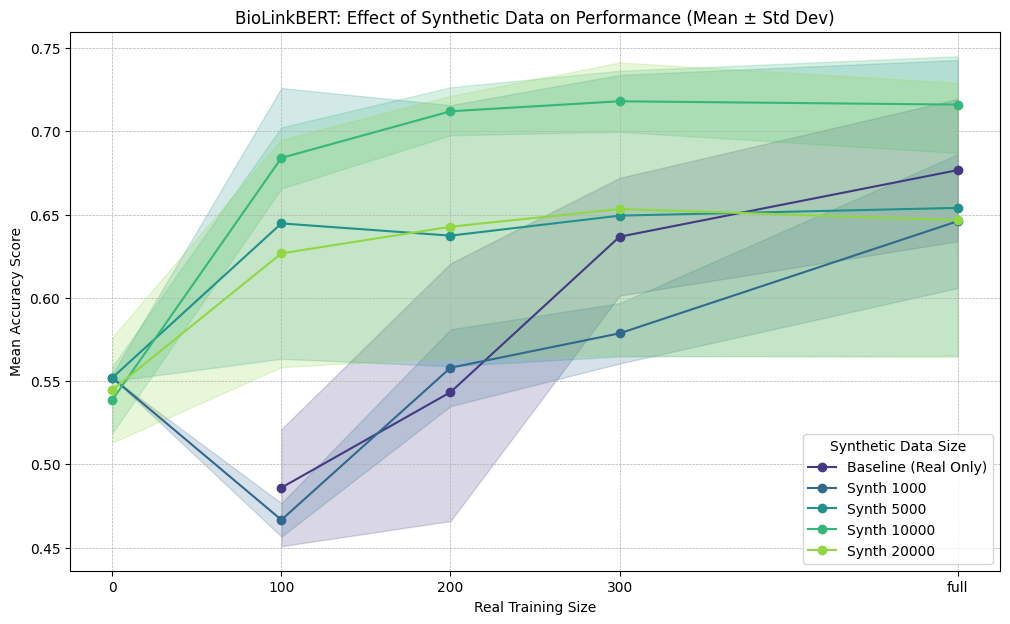

In [40]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy import stats


# --- Configuration ---
# Use the full path to your results directory
BASE_DIR = os.path.expanduser('~/kgqa/runs/pubmedqa_hf-new')
SEEDS = [
    # 'seed_42', 
         'seed_123', 
         'seed_456', 
         'seed_789', 
        #  'seed_1011'
         ] # Add all your seed directory names
FULL_DATA_SIZE = 500 # Define a numerical value for the 'full' dataset for plotting

# --- NEW: Filter for Debugging ---
# Add substrings to this list to only include runs that match.
# Leave empty (`[]`) to process all runs found in the directories.
# Example 1: To see only the baseline and the largest synthetic set:
RUN_FILTER = ["--train", "synth_1000", "synth_5000", "synth_10000", 
              "synth_20000"
              ]
# Example 2: To focus only on experiments involving 5000 real samples:
# RUN_FILTER = ["train_5000"]
# RUN_FILTER = []


# --- Data Parsing and Loading ---

def parse_run_name(run_name):
    """Parses the experiment run name to extract synthetic and real data sizes."""
    synth_size = 0
    real_size_str = "0"

    # Find synthetic data size
    synth_match = re.search(r'synth_(\d+)', run_name)
    if synth_match:
        synth_size = int(synth_match.group(1))

    # Find real data size
    train_match = re.search(r'train_(\w+)', run_name)
    if train_match:
        real_size_str = train_match.group(1)
        
    # Handle cases with only synthetic data (no 'train_' part)
    elif not train_match and synth_match:
        real_size_str = "0"
        
    # Handle cases with only real data (double hyphen is a good indicator)
    elif '--train' in run_name:
        synth_size = 0

    return synth_size, real_size_str

data = []
print(f"Searching for results in: {BASE_DIR}")
if RUN_FILTER:
    print(f"Applying filter. Including runs with: {RUN_FILTER}")


# Walk through the directory structure to find result files
for seed_dir in SEEDS:
    seed_path = os.path.join(BASE_DIR, seed_dir)
    if not os.path.isdir(seed_path):
        print(f"Warning: Directory not found for seed '{seed_dir}'. Skipping.")
        continue
        
    for root, dirs, files in os.walk(seed_path):
        if 'test_results.json' in files:
            # The run name is the directory containing the 'model' subdirectory
            run_name = os.path.basename(os.path.dirname(root))
            
            # <<< FILTERING LOGIC >>>
            # If a filter is active, check if the run name matches.
            # If not, skip to the next directory.
            if RUN_FILTER and not any(filt in run_name for filt in RUN_FILTER):
                continue
            
            try:
                # Parse the sizes from the directory name
                synth_size, real_label = parse_run_name(run_name)
                
                if real_label == 'full':
                    real_num = FULL_DATA_SIZE
                else:
                    real_num = int(real_label)

                # Load the score from the JSON file
                json_path = os.path.join(root, 'test_results.json')
                with open(json_path, 'r') as f:
                    results = json.load(f)
                    score = results.get('test_accuracy')
                    if score is not None:
                        data.append([seed_dir, synth_size, real_num, real_label, score])

            except (ValueError, TypeError) as e:
                print(f"Could not parse run '{run_name}'. Error: {e}. Skipping.")


# Create DataFrame from all collected data points
if not data:
    raise ValueError("No data found! Please check your BASE_DIR and SEEDS configuration, or adjust your RUN_FILTER.")

df_raw = pd.DataFrame(data, columns=["seed", "synthetic", "real_num", "real_label", "score"])

# Aggregate data to get mean and std dev
df_agg = df_raw.groupby(["synthetic", "real_num", "real_label"]).agg(
    score_mean=('score', 'mean'),
    score_std=('score', 'std')
).reset_index()

print("\n--- Aggregated Data ---")
print(df_agg)
print("---------------------\n")


# --- Plotting ---

# 1. Line Plot with Confidence Interval (Standard Deviation)
plt.figure(figsize=(12, 7))
palette = sns.color_palette("viridis", n_colors=df_agg["synthetic"].nunique())

for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
    label = f"Synth {synth_size}" if synth_size > 0 else "Baseline (Real Only)"
    plt.plot(group["real_num"], group["score_mean"], marker="o", linestyle="-", label=label, color=palette[i])
    plt.fill_between(
        group["real_num"],
        group["score_mean"] - group["score_std"],
        group["score_mean"] + group["score_std"],
        alpha=0.2,
        color=palette[i]
    )

plt.title("BioLinkBERT: Effect of Synthetic Data on Performance (Mean ± Std Dev)")
plt.xlabel("Real Training Size")
plt.ylabel("Mean Accuracy Score")
xticks_vals = sorted(df_agg["real_num"].unique())
xticks_labels = [str(x) if x != FULL_DATA_SIZE else "full" for x in xticks_vals]
plt.xticks(xticks_vals, xticks_labels)
plt.legend(title="Synthetic Data Size")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


# # 2. Heatmap of Mean Scores
# try:
#     pivot_df = df_agg.pivot(index="synthetic", columns="real_label", values="score_mean")
#     # Ensure columns are in a logical order
#     column_order = sorted(df_agg['real_label'].unique(), key=lambda x: FULL_DATA_SIZE if x == 'full' else int(x))
#     pivot_df = pivot_df[column_order]

#     plt.figure(figsize=(10, 7))
#     sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="viridis", linewidths=.5)
#     plt.title("BioLinkBERT Performance Heatmap: Mean Accuracy of Synthetic vs. Real Data")
#     plt.ylabel("Synthetic Data Size")
#     plt.xlabel("Real Training Size")
#     plt.show()
# except Exception as e:
#     print(f"Could not generate heatmap, likely due to filtered data structure. Error: {e}")


# # 3. Bar Chart with Automatic Error Bars (Confidence Intervals)
# plt.figure(figsize=(12, 7))
# column_order = sorted(df_agg['real_label'].unique(), key=lambda x: FULL_DATA_SIZE if x == 'full' else int(x))
# sns.barplot(
#     data=df_raw,
#     x="real_label",
#     y="score",
#     hue="synthetic",
#     palette="viridis",
#     order=column_order
# )
# plt.title("BioLinkBERT: Mean Accuracy per Real Training Size")
# plt.xlabel("Real Training Size")
# plt.ylabel("Mean Accuracy Score (with CI)")
# plt.legend(title="Synthetic Data Size")
# plt.grid(axis="y", linestyle="--", alpha=0.7)
# plt.show()

# plt.figure(figsize=(12, 7))
# palette = sns.color_palette("viridis", n_colors=df_agg["synthetic"].nunique())

# # Calculate n (number of seeds) for CI calculation
# num_seeds = len(SEEDS)
# # Get the t-statistic for a 95% CI with n-1 degrees of freedom
# # For 5 seeds, degrees of freedom = 4. If you change the number of seeds, this will adapt.
# t_value = stats.t.ppf(0.975, df=num_seeds - 1) if num_seeds > 1 else 1.96

# for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
#     label = f"Synth {synth_size}" if synth_size > 0 else "Baseline (Real Only)"
    
#     # Calculate Standard Error of the Mean (SEM)
#     sem = group['score_std'] / np.sqrt(num_seeds)
#     # Calculate the 95% Confidence Interval margin
#     ci_margin = t_value * sem
    
#     plt.plot(group["real_num"], group["score_mean"], marker="o", linestyle="-", label=label, color=palette[i])
#     plt.fill_between(
#         group["real_num"],
#         group["score_mean"] - ci_margin,
#         group["score_mean"] + ci_margin,
#         alpha=0.2,
#         color=palette[i]
#     )

# plt.title("BioLinkBERT: Effect of Synthetic Data on Performance (Mean with 95% CI)")
# plt.xlabel("Real Training Size")
# plt.ylabel("Mean Accuracy Score")
# xticks_vals = sorted(df_agg["real_num"].unique())
# xticks_labels = [str(x) if x != FULL_DATA_SIZE else "full" for x in xticks_vals]
# plt.xticks(xticks_vals, xticks_labels)
# plt.legend(title="Synthetic Data Size")
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()

In [41]:
print(df_raw.to_string())

        seed  synthetic  real_num real_label  score
0   seed_123       5000       300        300  0.704
1   seed_123       1000         0          0  0.552
2   seed_123       5000       200        200  0.706
3   seed_123      10000       300        300  0.698
4   seed_123       1000       300        300  0.558
5   seed_123       5000       100        100  0.704
6   seed_123          0       200        200  0.616
7   seed_123          0       100        100  0.512
8   seed_123          0       300        300  0.654
9   seed_123       1000       100        100  0.476
10  seed_123      20000       500       full  0.686
11  seed_123      10000         0          0  0.516
12  seed_123       5000       500       full  0.714
13  seed_123          0       500       full  0.726
14  seed_123      20000       100        100  0.686
15  seed_123       5000         0          0  0.550
16  seed_123      10000       100        100  0.680
17  seed_123       1000       500       full  0.600
18  seed_123


--- Loading data for: 'PubMedQA' ---
Searching in: /home/id.aau.dk/kr75cs/kgqa/runs/pubmedqa_hf-new

--- Loading data for: 'MedQA' ---
Searching in: /home/id.aau.dk/kr75cs/kgqa/runs/medqa_usmle_hf-new
    synthetic  real_num    mean       std
0           0       100  0.4916  0.035423
1           0       200  0.5428  0.054728
2           0       300  0.6524  0.033118
3           0       500  0.6764  0.042365
4        1000         0  0.5520  0.000000
5        1000       100  0.4824  0.039659
6        1000       200  0.5408  0.030548
7        1000       300  0.5644  0.024224
8        1000       500  0.6084  0.072504
9        5000         0  0.5520  0.001414
10       5000       100  0.6216  0.076255
11       5000       200  0.6292  0.075586
12       5000       300  0.6552  0.064909
13       5000       500  0.6716  0.067622
14      10000         0  0.5412  0.015007
15      10000       100  0.6848  0.017239
16      10000       200  0.7020  0.034871
17      10000       300  0.7032  0.028270


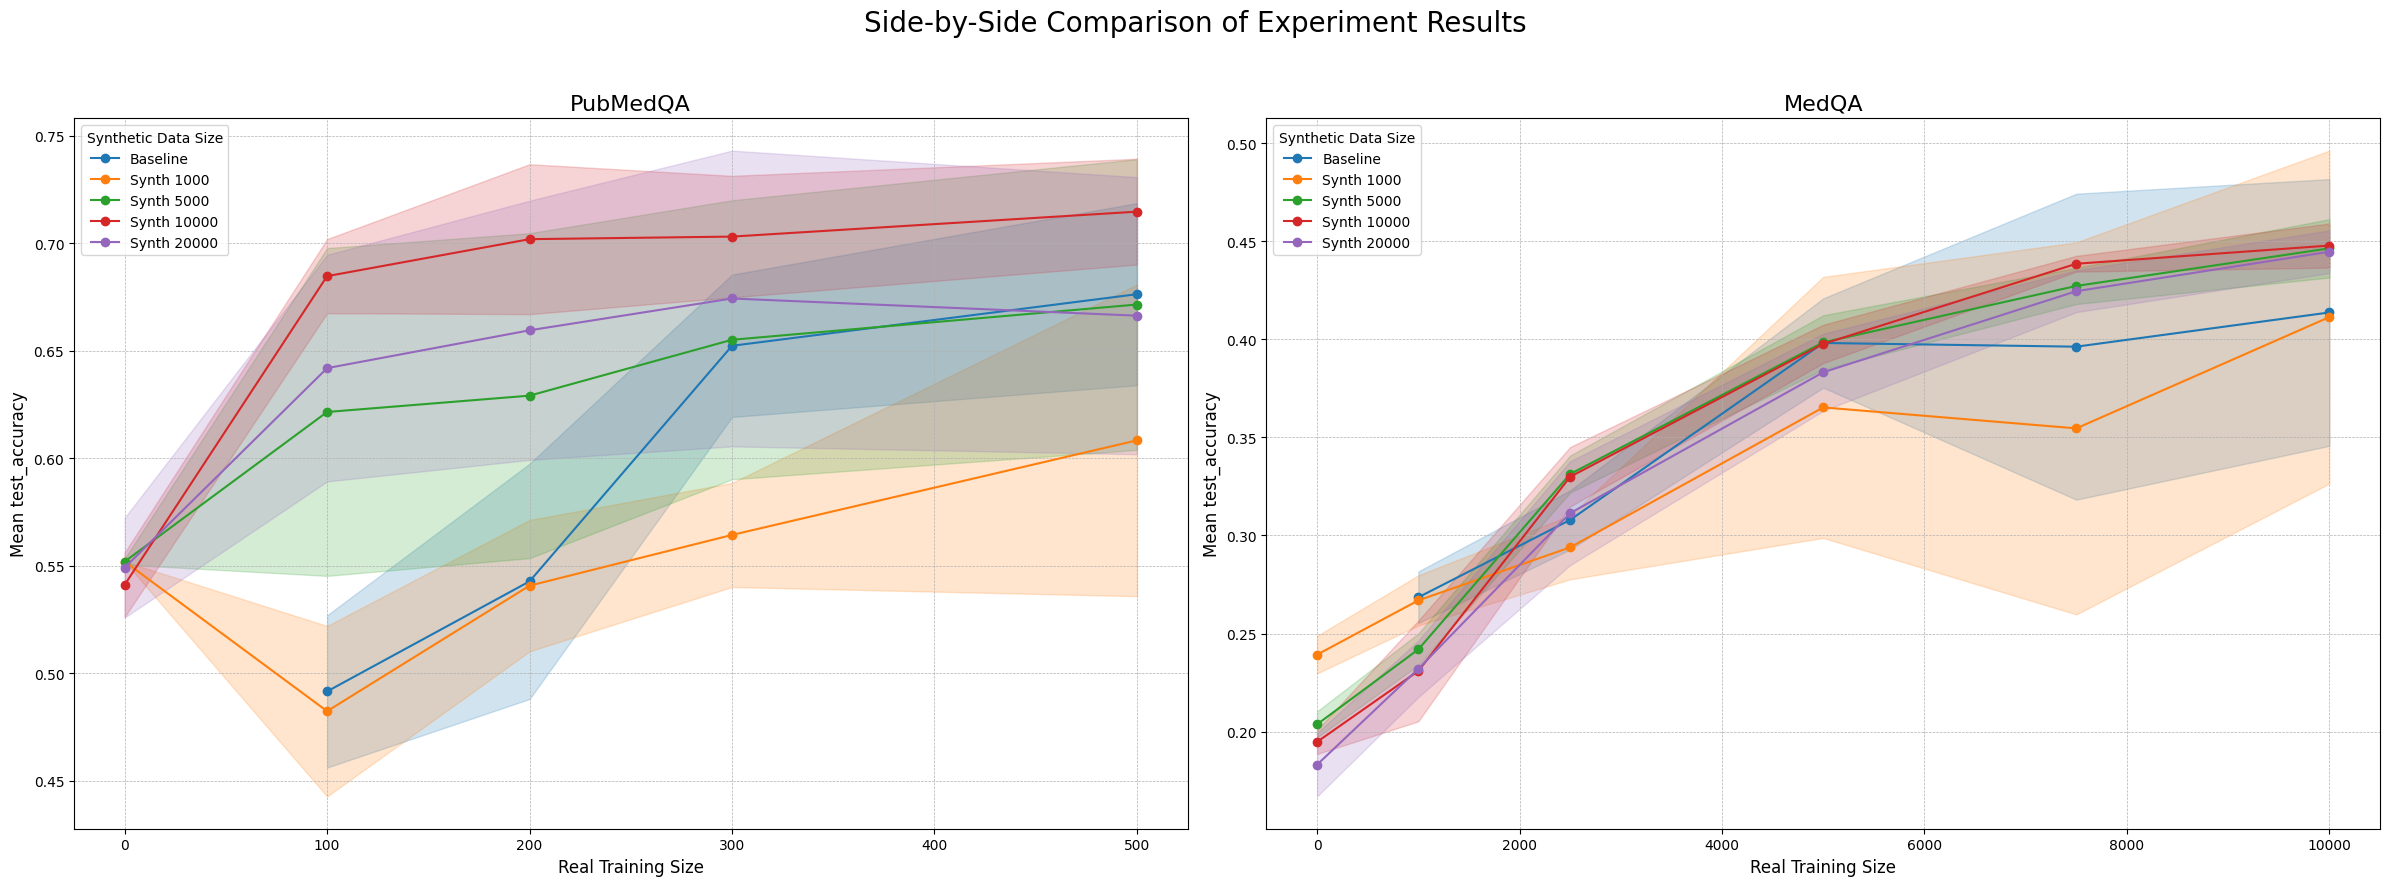

In [9]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# ==============================================================================
# --- 1. CONFIGURATION FOR TWO COMPLETELY DIFFERENT EXPERIMENTS ---
# ==============================================================================
#
#  <<< EDIT THIS SECTION CAREFULLY >>>
#  Provide all the unique details for each of your two experiments below.
#
EXPERIMENT_1_CONFIG = {
    'name': 'PubMedQA',  # A descriptive name for the plot title
    'base_dir': os.path.expanduser('~/kgqa/runs/pubmedqa_hf-new'),
    'seeds': ['seed_42', 'seed_123', 'seed_456', 'seed_789',  'seed_1011'],
    'full_data_size': 500,
    'run_filter': ["--train", "synth_1000", "synth_5000", "synth_10000", "synth_20000"],
    
    # --- Unique file and key names for this experiment ---
    'results_filename': 'all_results.json', # The exact name of the results file
    'metric_key': 'test_accuracy'           # The exact key for the score in the JSON
}

EXPERIMENT_2_CONFIG = {
    'name': 'MedQA', # A different name for the second plot
    'base_dir': os.path.expanduser('~/kgqa/runs/medqa_usmle_hf-new'), # <<< A DIFFERENT DIRECTORY
    'seeds': ['seed_42', 'seed_123', 'seed_456', 'seed_789',  'seed_1011'],
    'full_data_size': 10000, # Can be different
    'run_filter': ["--train", "synth_1000", "synth_5000", "synth_10000", "synth_20000"],
    
    # --- Unique file and key names for this experiment ---
    'results_filename': 'all_results.json', # <<< A DIFFERENT FILENAME
    'metric_key': 'test_accuracy'               # <<< A DIFFERENT METRIC KEY
}

# ==============================================================================
# --- 2. MODULAR DATA PARSING AND LOADING ---
# ==============================================================================

def parse_run_name(run_name):
    """Parses run names. Can be adapted if naming conventions differ drastically."""
    synth_size = 0
    real_size_str = "0"
    # This regex is flexible enough for 'synth_1000' or 'train_size_500' etc.
    synth_match = re.search(r'synth_(\d+)', run_name)
    if synth_match:
        synth_size = int(synth_match.group(1))
    train_match = re.search(r'train[_-](\w+)', run_name) # Handles train_ or train-
    if train_match:
        real_size_str = train_match.group(1)
    elif '--train' in run_name or 'baseline' in run_name:
        synth_size = 0 # Baseline case
    return synth_size, real_size_str

def load_experiment_data(config):
    """Loads all data for a single, complete experiment configuration."""
    data = []
    print(f"\n--- Loading data for: '{config['name']}' ---")
    print(f"Searching in: {config['base_dir']}")

    if not os.path.isdir(config['base_dir']):
        print(f"!!! WARNING: Directory not found for '{config['name']}'. Skipping.")
        return None

    for seed_dir in config['seeds']:
        seed_path = os.path.join(config['base_dir'], seed_dir)
        if not os.path.isdir(seed_path):
            continue
        for root, _, files in os.walk(seed_path):
            if config['results_filename'] in files:
                run_name = os.path.basename(os.path.dirname(root))
                if config['run_filter'] and not any(filt in run_name for filt in config['run_filter']):
                    continue
                try:
                    synth_size, real_label = parse_run_name(run_name)
                    real_num = config['full_data_size'] if real_label == 'full' else int(real_label)
                    
                    json_path = os.path.join(root, config['results_filename'])
                    with open(json_path, 'r') as f:
                        results = json.load(f)
                    
                    score = results.get(config['metric_key'])
                    if score is not None:
                        data.append([seed_dir, synth_size, real_num, real_label, score])
                except (ValueError, TypeError) as e:
                    print(f"Could not parse run '{run_name}'. Error: {e}. Skipping.")
    
    if not data:
        print(f"!!! WARNING: No data found for '{config['name']}'. Check paths, filters, and filenames.")
        return None
        
    return pd.DataFrame(data, columns=["seed", "synthetic", "real_num", "real_label", "score"])

# ==============================================================================
# --- 3. REUSABLE PLOTTING FUNCTION ---
# ==============================================================================

def plot_experiment_results(ax, df, config):
    """Generic function to plot the results (Mean +/- Std Dev) for one experiment."""
    if df is None:
        ax.text(0.5, 0.5, 'Data not found', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(f"{config['name']}", fontsize=16)
        return

    df_agg = df.groupby(["synthetic", "real_num"]).agg(mean=('score', 'mean'), std=('score', 'std')).reset_index()
    print(df_agg.to_string())
    palette = sns.color_palette("tab10", n_colors=df_agg["synthetic"].nunique())
    
    for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
        label = f"Synth {synth_size}" if synth_size > 0 else "Baseline"
        ax.plot(group["real_num"], group["mean"], marker="o", linestyle="-", label=label, color=palette[i])
        ax.fill_between(group["real_num"], group["mean"] - group["std"], group["mean"] + group["std"], alpha=0.2, color=palette[i])
        
    ax.set_title(f"{config['name']}", fontsize=16)
    ax.set_xlabel("Real Training Size", fontsize=12)
    ax.set_ylabel(f"Mean {config['metric_key']}", fontsize=12)
    ax.legend(title="Synthetic Data Size")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)


# ==============================================================================
# --- 3. REUSABLE BOX PLOT FUNCTION ---
# ==============================================================================

def plot_experiment_distribution_boxplot(ax, df, config):
    """
    Generic function to plot the results distribution (Box Plot + Strip Plot) for one experiment.
    `ax`: The matplotlib axis to plot on.
    `df`: The raw DataFrame for the experiment.
    `config`: The configuration dictionary for the experiment.
    """
    # Handle case where data loading failed
    if df is None:
        ax.text(0.5, 0.5, 'Data not found', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(f"Distribution for {config['name']}", fontsize=16)
        return

    # Define a logical order for the x-axis categories
    column_order = sorted(df['real_label'].unique(), key=lambda x: config['full_data_size'] if x == 'full' else int(x))
    
    # Create the main box plot
    sns.boxplot(
        data=df,
        x="real_label",
        y="score",
        hue="synthetic",
        palette="tab10",
        order=column_order,
        ax=ax
    )
    
    # Overlay the individual data points for more detail
    sns.stripplot(
        data=df,
        x="real_label",
        y="score",
        hue="synthetic",
        palette="tab10",
        order=column_order,
        dodge=True,
        jitter=0.1,
        alpha=0.7,
        linewidth=1,
        edgecolor='gray',
        ax=ax
    )
    
    ax.set_title(f"Distribution for {config['name']}", fontsize=16)
    ax.set_xlabel("Real Training Size", fontsize=12)
    ax.set_ylabel(f"Score ({config['metric_key']})", fontsize=12)
    
    # Clean up the legend, as stripplot creates duplicate entries
    handles, labels = ax.get_legend_handles_labels()
    n_hues = df['synthetic'].nunique()
    ax.legend(handles[:n_hues], labels[:n_hues], title="Synthetic Data Size")
    ax.grid(axis="y", linestyle="--", alpha=0.7)




# ==============================================================================
# --- 4. MAIN EXECUTION SCRIPT ---
# ==============================================================================

# Load data for both experiments using their respective configurations
df1 = load_experiment_data(EXPERIMENT_1_CONFIG)
df2 = load_experiment_data(EXPERIMENT_2_CONFIG)

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Side-by-Side Comparison of Experiment Results', fontsize=20)

# Plot the results for each experiment on its own axis
plot_experiment_results(ax1, df1, EXPERIMENT_1_CONFIG)
plot_experiment_results(ax2, df2, EXPERIMENT_2_CONFIG)

# Show the final combined plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('comparison_line.pdf', bbox_inches='tight')

plt.show()


# # Create the figure with two subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9))
# fig.suptitle('Side-by-Side Comparison of Experiment Result Distributions', fontsize=20)

# # Plot the results for each experiment on its own axis
# plot_experiment_distribution_boxplot(ax1, df1, EXPERIMENT_1_CONFIG)
# plot_experiment_distribution_boxplot(ax2, df2, EXPERIMENT_2_CONFIG)

# # Show the final combined plot
# plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('comparison_boxplot.pdf', bbox_inches='tight')

# plt.show()


In [4]:
df1

,seed,synthetic,real_num,real_label,score
0,seed_42,5000,300,300,0.698
1,seed_42,1000,0,0,0.552
2,seed_42,5000,200,200,0.688
3,seed_42,10000,300,300,0.702
4,seed_42,1000,300,300,0.552
...,...,...,...,...,...
115,seed_1011,20000,300,300,0.698
116,seed_1011,20000,200,200,0.690
117,seed_1011,10000,200,200,0.644
118,seed_1011,10000,500,full,0.694


In [43]:
print(df_raw.to_string())

        seed  synthetic  real_num real_label  score
0   seed_123       5000       300        300  0.704
1   seed_123       1000         0          0  0.552
2   seed_123       5000       200        200  0.706
3   seed_123      10000       300        300  0.698
4   seed_123       1000       300        300  0.558
5   seed_123       5000       100        100  0.704
6   seed_123          0       200        200  0.616
7   seed_123          0       100        100  0.512
8   seed_123          0       300        300  0.654
9   seed_123       1000       100        100  0.476
10  seed_123      20000       500       full  0.686
11  seed_123      10000         0          0  0.516
12  seed_123       5000       500       full  0.714
13  seed_123          0       500       full  0.726
14  seed_123      20000       100        100  0.686
15  seed_123       5000         0          0  0.550
16  seed_123      10000       100        100  0.680
17  seed_123       1000       500       full  0.600
18  seed_123

In [45]:
# import os
# import json
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# import re
# from scipy import stats

# # ==============================================================================
# # --- 1. CONFIGURATION ---
# # ==============================================================================

# # --- Define the two metrics you want to extract and plot from the JSON files ---
# # IMPORTANT: These must be the exact keys in your test_results.json file.
# METRICS_TO_PLOT = {
#     'metric1': 'test_accuracy',
#     'metric2': 'test_f1' # Example: change to 'test_precision' or another metric
# }

# # --- General experiment configuration ---
# BASE_DIR = os.path.expanduser('~/kgqa/runs/pubmedqa_hf-new')
# SEEDS = ['seed_123', 'seed_456', 'seed_789']
# FULL_DATA_SIZE = 500
# RUN_FILTER = ["--train", "synth_1000", "synth_5000", "synth_10000", "synth_20000"]

# # ==============================================================================
# # --- 2. UNIFIED DATA PARSING AND LOADING ---
# # ==============================================================================

# def parse_run_name(run_name):
#     """Parses the experiment run name to extract synthetic and real data sizes."""
#     synth_size = 0
#     real_size_str = "0"
#     synth_match = re.search(r'synth_(\d+)', run_name)
#     if synth_match:
#         synth_size = int(synth_match.group(1))
#     train_match = re.search(r'train_(\w+)', run_name)
#     if train_match:
#         real_size_str = train_match.group(1)
#     elif not train_match and synth_match:
#         real_size_str = "0"
#     elif '--train' in run_name:
#         synth_size = 0
#     return synth_size, real_size_str

# data = []
# print(f"Searching for results in: {BASE_DIR}")
# if RUN_FILTER:
#     print(f"Applying filter. Including runs with: {RUN_FILTER}")

# # Walk through the directory structure to find result files
# for seed_dir in SEEDS:
#     seed_path = os.path.join(BASE_DIR, seed_dir)
#     if not os.path.isdir(seed_path):
#         continue
#     for root, _, files in os.walk(seed_path):
#         if 'test_results.json' in files:
#             run_name = os.path.basename(os.path.dirname(root))
#             if RUN_FILTER and not any(filt in run_name for filt in RUN_FILTER):
#                 continue
#             try:
#                 synth_size, real_label = parse_run_name(run_name)
#                 real_num = FULL_DATA_SIZE if real_label == 'full' else int(real_label)
                
#                 json_path = os.path.join(root, 'test_results.json')
#                 with open(json_path, 'r') as f:
#                     results = json.load(f)
                
#                 # Extract both metrics from the same file
#                 score1 = results.get(METRICS_TO_PLOT['metric1'])
#                 score2 = results.get(METRICS_TO_PLOT['metric2'])
                
#                 # Append if both scores are found
#                 if score1 is not None and score2 is not None:
#                     row = [seed_dir, synth_size, real_num, real_label, score1, score2]
#                     data.append(row)
#             except (ValueError, TypeError) as e:
#                 print(f"Could not parse run '{run_name}'. Error: {e}. Skipping.")

# if not data:
#     raise ValueError("No data found! Check configuration, paths, and metric keys.")

# # Create a single DataFrame with columns for both metrics
# df_raw = pd.DataFrame(data, columns=["seed", "synthetic", "real_num", "real_label", 
#                                      METRICS_TO_PLOT['metric1'], METRICS_TO_PLOT['metric2']])
# print("\n--- Unified Data Loaded ---")
# print(df_raw.head())
# print("---------------------------\n")

# # ==============================================================================
# # --- 3. REUSABLE PLOTTING FUNCTION ---
# # ==============================================================================

# def plot_metric_trend(ax, df, metric_name, title):
#     """
#     Generic function to plot a metric's trend using Mean +/- Std Dev.
#     `ax`: The matplotlib axis to plot on.
#     `df`: The raw DataFrame.
#     `metric_name`: The string name of the column to plot (e.g., 'test_accuracy').
#     `title`: The title for the subplot.
#     """
#     # Aggregate data specifically for the given metric
#     df_agg = df.groupby(["synthetic", "real_num", "real_label"]).agg(
#         mean=(metric_name, 'mean'),
#         std=(metric_name, 'std')
#     ).reset_index()
    
#     palette = sns.color_palette("tab10", n_colors=df_agg["synthetic"].nunique())
    
#     for i, (synth_size, group) in enumerate(df_agg.sort_values(by="real_num").groupby("synthetic")):
#         label = f"Synth {synth_size}" if synth_size > 0 else "Baseline"
#         ax.plot(group["real_num"], group["mean"], marker="o", linestyle="-", label=label, color=palette[i])
#         ax.fill_between(
#             group["real_num"],
#             group["mean"] - group["std"],
#             group["mean"] + group["std"],
#             alpha=0.2,
#             color=palette[i]
#         )
        
#     ax.set_title(title, fontsize=16)
#     ax.set_xlabel("Real Training Size", fontsize=12)
#     ax.set_ylabel(f"Mean {metric_name}", fontsize=12)
    
#     xticks_vals = sorted(df_agg["real_num"].unique())
#     xticks_labels = [str(x) if x != FULL_DATA_SIZE else "full" for x in xticks_vals]
#     ax.set_xticks(xticks_vals)
#     ax.set_xticklabels(xticks_labels)
#     ax.legend(title="Synthetic Data Size")
#     ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# # ==============================================================================
# # --- 4. MAIN PLOTTING EXECUTION ---
# # ==============================================================================

# # Create a figure with two subplots side-by-side
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 9))
# metric1_key = METRICS_TO_PLOT['metric1']
# metric2_key = METRICS_TO_PLOT['metric2']

# fig.suptitle(f'Side-by-Side Comparison: {metric1_key} vs. {metric2_key}', fontsize=20)

# # --- Plot Metric 1 on the left subplot (ax1) ---
# plot_metric_trend(ax1, df_raw, metric_name=metric1_key, title=f"Performance Trend for {metric1_key}")

# # --- Plot Metric 2 on the right subplot (ax2) ---
# plot_metric_trend(ax2, df_raw, metric_name=metric2_key, title=f"Performance Trend for {metric2_key}")

# # --- Final Adjustments & Display ---
# plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect for suptitle
# plt.show()